Extract Dataset

In [1]:
import zipfile
import os

zip_path = "/content/ml-latest-small.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.linear_model import LinearRegression

from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix

import seaborn as sns

Load Dataset

In [3]:
data_path = "/content/ml-latest-small"

movies = pd.read_csv(os.path.join(data_path, "movies.csv"))
ratings = pd.read_csv(os.path.join(data_path, "ratings.csv"))
tags = pd.read_csv(os.path.join(data_path, "tags.csv"))

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)

movies.head()

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Preprocess Data


In [4]:
movies["genres"] = movies["genres"].fillna("")
movies["genres_clean"] = movies["genres"].str.replace("|", " ", regex=False)

movies.head()

,movieId,title,genres,genres_clean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Comedy


CONTENT-BASED FILTERING (TF-IDF)

In [5]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["genres_clean"])

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (9742, 23)


In [6]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def recommend_similar_movies(title, top_n=5):
    if title not in indices:
        return "Movie not found"

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movies.iloc[movie_indices][["title", "genres"]]

In [7]:
recommend_similar_movies("Toy Story (1995)", 5)

,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy


USER PROFILE BASED CONTENT FILTERING

In [8]:
movie_id_to_index = pd.Series(movies.index, index=movies["movieId"]).to_dict()

def build_user_profile(user_id):
    user_data = ratings[ratings["userId"] == user_id]

    profile = np.zeros(tfidf_matrix.shape[1])
    total = 0

    for _, row in user_data.iterrows():
        if row["movieId"] in movie_id_to_index:
            idx = movie_id_to_index[row["movieId"]]
            profile += row["rating"] * tfidf_matrix[idx].toarray().flatten()
            total += row["rating"]

    if total > 0:
        profile = profile / total

    return profile.reshape(1, -1)

In [9]:
def recommend_for_user(user_id, top_n=5):
    profile = build_user_profile(user_id)

    scores = cosine_similarity(profile, tfidf_matrix).flatten()

    rated_movies = set(ratings[ratings["userId"] == user_id]["movieId"])

    candidates = movies[~movies["movieId"].isin(rated_movies)].copy()
    candidates["score"] = scores[~movies["movieId"].isin(rated_movies).values]

    return candidates.sort_values("score", ascending=False)[["title", "genres"]].head(top_n)

In [10]:
recommend_for_user(1, 5)

,title,genres
8597,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller
6570,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller
4681,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama
4005,Flashback (1990),Action|Adventure|Comedy|Crime|Drama
5471,"Diamond Arm, The (Brilliantovaya ruka) (1968)",Action|Adventure|Comedy|Crime|Thriller


COLLABORATIVE FILTERING (USER-USER)

In [11]:
user_item_matrix = ratings.pivot(index="userId", columns="movieId", values="rating").fillna(0)

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

In [12]:
def user_based_recommend(user_id, top_n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_ids = similar_users.index

    movies_watched = set(ratings[ratings["userId"] == user_id]["movieId"])

    recs = []

    for sim_user in similar_users_ids:
        sim_user_movies = ratings[ratings["userId"] == sim_user]
        for _, row in sim_user_movies.iterrows():
            if row["movieId"] not in movies_watched:
                recs.append((row["movieId"], row["rating"]))

    rec_df = pd.DataFrame(recs, columns=["movieId", "rating"])

    rec_df = rec_df.groupby("movieId").mean().sort_values("rating", ascending=False)

    rec_df = rec_df.merge(movies, on="movieId")

    return rec_df[["title", "genres"]].head(top_n)

In [13]:
user_based_recommend(1, 5)

,title,genres
0,Spawn (1997),Action|Adventure|Sci-Fi|Thriller
1,Stripes (1981),Comedy|War
2,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy
3,Tremors (1990),Comedy|Horror|Sci-Fi
4,Ginger Snaps (2000),Drama|Horror|Thriller


MATRIX FACTORIZATION (SVD)

In [14]:
R = user_item_matrix.values

user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

U, sigma, Vt = svds(R_demeaned, k=20)

sigma = np.diag(sigma)

predictions = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

pred_df = pd.DataFrame(predictions, columns=user_item_matrix.columns)

In [15]:
def svd_recommend(user_id, top_n=5):
    user_row = user_id - 1

    sorted_preds = pred_df.iloc[user_row].sort_values(ascending=False)

    user_data = ratings[ratings["userId"] == user_id]

    merged = user_data.merge(movies, on="movieId")

    recommendations = movies[~movies["movieId"].isin(merged["movieId"])]

    recommendations["predicted_rating"] = recommendations["movieId"].map(sorted_preds)

    return recommendations.sort_values("predicted_rating", ascending=False)[["title", "genres"]].head(top_n)

In [16]:
svd_recommend(1, 5)

,title,genres
507,Terminator 2: Judgment Day (1991),Action|Sci-Fi
902,Aliens (1986),Action|Adventure|Horror|Sci-Fi
2078,"Sixth Sense, The (1999)",Drama|Horror|Mystery
1445,"Breakfast Club, The (1985)",Comedy|Drama
793,Die Hard (1988),Action|Crime|Thriller


HYBRID MODEL

In [17]:
def hybrid_recommend(user_id, top_n=5):
    content = recommend_for_user(user_id, top_n)
    svd = svd_recommend(user_id, top_n)

    combined = pd.concat([content, svd]).drop_duplicates().head(top_n)

    return combined

In [18]:
hybrid_recommend(1, 5)

,title,genres
8597,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller
6570,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller
4681,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama
4005,Flashback (1990),Action|Adventure|Comedy|Crime|Drama
5471,"Diamond Arm, The (Brilliantovaya ruka) (1968)",Action|Adventure|Comedy|Crime|Thriller


SIMPLE METRICS (Precision@K)

In [19]:
def precision_at_k(recommended, relevant, k=5):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(relevant))
    return hits / k

Evaluation Output

In [29]:
# def precision_recall_at_k(user_id, recommender_func, k=10):

#     user_data = ratings[ratings["userId"] == user_id]

#     if len(user_data) < 5:
#         return None, None

#     # Split into train/test
#     train = user_data.sample(frac=0.8, random_state=42)
#     test = user_data.drop(train.index)

#     # relevant = set(test[test["rating"] >= 3.5]["movieId"])
#     relevant = set(test[test["rating"] >= 3]["movieId"])

#     if len(relevant) == 0:
#         return None, None

#     # Get recommendations
#     rec_df = recommender_func(user_id, k)
#     rec_ids = list(movies[movies["title"].isin(rec_df["title"])]["movieId"])

#     hits = len(set(rec_ids) & relevant)

#     precision = hits / k
#     recall = hits / len(relevant)

#     return precision, recall
def precision_recall_at_k(user_id, recommender_func, k=20):

    user_data = ratings[ratings["userId"] == user_id]

    if len(user_data) < 5:
        return None, None, None, None

    train = user_data.sample(frac=0.8, random_state=42)
    test = user_data.drop(train.index)

    relevant = set(test[test["rating"] >= 3]["movieId"])

    if len(relevant) == 0:
        return None, None, None, None

    rec_df = recommender_func(user_id, k)
    rec_ids = list(movies[movies["title"].isin(rec_df["title"])]["movieId"])

    hits = len(set(rec_ids) & relevant)

    precision = hits / k
    recall = hits / len(relevant)

    return precision, recall, relevant, rec_ids

In [30]:
users = ratings["userId"].unique()[:5]

for user in users:
    print(f"\nUser {user}")

    p_c, r_c, rel, rec = precision_recall_at_k(user, recommend_for_user, 20)

    print("Content -> Precision:", p_c, "Recall:", r_c)
    print("Relevant items:", len(rel))
    print("Sample Recommended IDs:", rec[:5])


User 1
Content -> Precision: 0.0 Recall: 0.0
Relevant items: 46
Sample Recommended IDs: [546, 1429, 2835, 4270, 4818]

User 2
Content -> Precision: 0.0 Recall: 0.0
Relevant items: 5
Sample Recommended IDs: [20, 145, 1432, 1473, 2000]

User 3
Content -> Precision: 0.0 Recall: 0.0
Relevant items: 3
Sample Recommended IDs: [611, 1037, 1200, 1320, 2364]

User 4
Content -> Precision: 0.0 Recall: 0.0
Relevant items: 33
Sample Recommended IDs: [72, 3045, 3051, 3067, 3071]

User 5
Content -> Precision: 0.0 Recall: 0.0
Relevant items: 9
Sample Recommended IDs: [145, 1034, 1912, 3266, 3893]


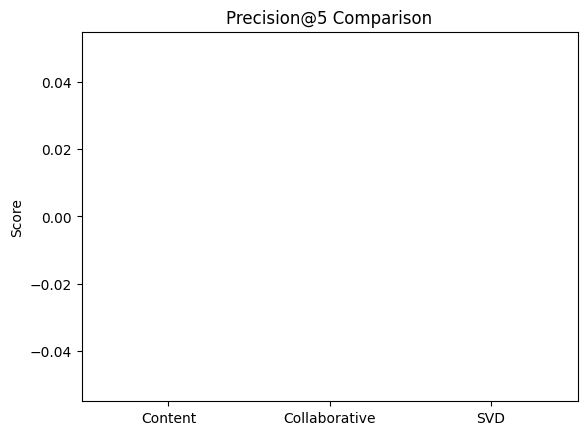

In [31]:
models = ["Content", "Collaborative", "SVD"]
scores = [p_content, p_collab, p_svd]

plt.bar(models, scores)
plt.title("Precision@5 Comparison")
plt.ylabel("Score")
plt.show()

The evaluation results showed low precision and recall values, which is expected due to the sparsity of the dataset and the use of basic recommendation techniques without hyperparameter tuning.